# Steam 市场结构分析：发行、价格、平台与内容生态

本 Notebook 延续 `03_steam_data_cleaning_and_features.ipynb` 的结果，使用已经清洗和特征工程后的 Parquet 数据，分析 Steam 游戏市场的供给结构。

本部分关注的问题是：Steam 游戏市场由什么构成？游戏发行时间、价格、平台支持、类型、标签、开发商和发行商是否呈现出明显的结构特征？这些分析可以帮助我们把一个复杂的大规模表格数据集，转化为更适合课程报告表达的市场洞察。

## 1. 读取特征数据并检查字段

前一个 Notebook 已经把原始 CSV 转换成了 `data/processed/steam_march2025_features.parquet`。本节优先读取这个 Parquet 文件，避免每次重复读取几百 MB 的原始 CSV。

如果该文件不存在，说明需要先运行 Notebook 03。

In [1]:
from pathlib import Path
from datetime import datetime
import ast
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RAW_DIR = DATA_DIR / "raw" / "archive"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_PATH = PROCESSED_DIR / "steam_march2025_features.parquet"

if not FEATURE_PATH.exists():
    raise FileNotFoundError(
        f"未找到 {FEATURE_PATH}。请先运行 notebooks/03_steam_data_cleaning_and_features.ipynb，"
        "生成清洗后的特征数据。"
    )

df = pd.read_parquet(FEATURE_PATH)
print(f"Loaded feature dataset: {FEATURE_PATH}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())

Loaded feature dataset: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_march2025_features.parquet
Shape: 89,618 rows x 63 columns


,appid,name,release_date,required_age,price,discount,dlc_count,windows,mac,linux,metacritic_score,achievements,recommendations,developers,publishers,categories,genres,user_score,positive,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,supported_languages,full_audio_languages,short_description,about_the_game,release_date_parsed,release_year,game_age_years,genres_list,genres_count,categories_list,categories_count,tags_list,tags_count,developers_list,developers_count,publishers_list,publishers_count,supported_languages_list,supported_languages_count,full_audio_languages_list,full_audio_languages_count,is_free,platform_count,is_multi_platform,review_count_calc,positive_rate_calc,negative_rate_calc,short_description_length,about_the_game_length,has_peak_ccu,peak_ccu_log1p,recommendations_log1p
0,730,Counter-Strike 2,2012-08-21,0,0.00,0,1,True,False,True,0,1,4401572,['Valve'],['Valve'],"['Multi-player', 'Cross-Platform Multiplayer',...","['Action', 'Free To Play']",0,7480813,1135108,100000000 - 200000000,33189,879,5174,350,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86.00,8632939,82.00,96473,"['Czech', 'Danish', 'Dutch', 'English', 'Finni...","['English', 'Indonesian']","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",2012-08-21,2012,14.00,Action|Free To Play,2,Multi-player|Cross-Platform Multiplayer|Steam ...,11,FPS|Shooter|Multiplayer|Competitive|Action|Tea...,20,Valve,1,Valve,1,Czech|Danish|Dutch|English|Finnish|French|Germ...,29,English|Indonesian,2,True,2,True,8615921,86.83,13.17,224,879,True,14.01,15.30
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,0,True,False,False,0,37,1732007,['PUBG Corporation'],"['KRAFTON, Inc.']","['Multi-player', 'PvP', 'Online PvP', 'Stats',...","['Action', 'Adventure', 'Massively Multiplayer...",0,1487960,1024436,50000000 - 100000000,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59.00,2513842,68.00,16720,"['English', 'Korean', 'Simplified Chinese', 'F...",[],Play PUBG: BATTLEGROUNDS for free. Land on str...,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",2017-12-21,2017,9.00,Action|Adventure|Massively Multiplayer|Free To...,4,Multi-player|PvP|Online PvP|Stats|Remote Play ...,6,Survival|Shooter|Battle Royale|Multiplayer|FPS...,20,PUBG Corporation,1,"KRAFTON, Inc.",1,English|Korean|Simplified Chinese|French|Germa...,17,,0,True,1,False,2512396,59.22,40.78,293,478,True,13.33,14.36
2,570,Dota 2,2013-07-09,0,0.00,0,2,True,True,True,90,0,14337,['Valve'],['Valve'],"['Multi-player', 'Co-op', 'Steam Trading Cards...","['Action', 'Strategy', 'Free To Play']",0,1998462,451338,200000000 - 500000000,43031,1536,898,892,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81.00,2452595,80.00,29366,"['Bulgarian', 'Czech', 'Danish', 'Dutch', 'Eng...","['English', 'Korean', 'Simplified Chinese', 'V...","Every day, millions of players worldwide enter...","The most-played game on Steam. Every day, mill...",2013-07-09,2013,13.00,Action|Strategy|Free To Play,3,Multi-player|Co-op|Steam Trading Cards|Steam W...,8,Free to Play|MOBA|Multiplayer|Strategy|e-sport...,20,Valve,1,Valve,1,Bulgarian|Czech|Danish|Dutch|English|Finnish|F...,28,English|Korean|Simplified Chinese|Vietnamese,4,True,3,True,2449800,81.58,18.42,319,1402,True,13.23,9.57
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,0,True,False,False,96,77,1803063,['Rockstar North'],['Rockstar Games'],"['Single-player', 'Multi-player', 'PvP', 'Onli...","['Action', 'Adventure']",0,1719950,250012,50000000 - 100000000,19323,771,7101,74,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87.00,1803832,92.00,17517,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'Spanish - Latin America']",Grand Theft Auto V for PC offers players the o...,"When a young street hustler, a retired bank ro...",2015-

In [2]:
# 检查本 Notebook 会用到的关键字段是否存在。
required_columns = [
    "appid", "name", "release_year", "price", "is_free",
    "windows", "mac", "linux", "platform_count", "is_multi_platform",
    "genres", "categories", "tags", "developers", "publishers",
    "genres_count", "categories_count", "tags_count",
    "review_count_calc", "positive_rate_calc", "recommendations", "peak_ccu"
]

column_check = pd.DataFrame({
    "column": required_columns,
    "exists": [col in df.columns for col in required_columns]
})

display(column_check)
missing_required = column_check.loc[~column_check["exists"], "column"].tolist()
if missing_required:
    print("Warning: 以下字段不存在，相关分析会自动跳过或降级处理：", missing_required)
else:
    print("All required columns are available.")

,column,exists
0,appid,True
1,name,True
2,release_year,True
3,price,True
4,is_free,True
5,windows,True
6,mac,True
7,linux,True
8,platform_count,True
9,is_multi_platform,True


All required columns are available.


## 2. 分析辅助函数与多标签字段整理

Steam 数据中的 `genres`、`categories`、`tags`、`developers` 和 `publishers` 都可能是一条记录对应多个值。为了统计市场结构，需要把这些字段解析成列表，并在需要时展开成长表。

这里不改变原始字段，而是新增 `_items` 辅助列，保证后续分析既可复现，也不会破坏前一步保存的数据。

In [3]:
def parse_multivalue(value):
    """把字符串形式的 list/dict 或普通分隔字符串，转换成干净的 Python list。"""
    if value is None:
        return []
    if isinstance(value, float) and pd.isna(value):
        return []
    if isinstance(value, list):
        raw_items = value
    elif isinstance(value, dict):
        raw_items = list(value.keys())
    else:
        text = str(value).strip()
        if not text or text.lower() in {"nan", "none", "[]", "{}"}:
            return []
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, dict):
                raw_items = list(parsed.keys())
            elif isinstance(parsed, (list, tuple, set)):
                raw_items = list(parsed)
            else:
                raw_items = [parsed]
        except (ValueError, SyntaxError):
            # 兼容少数不是标准 Python 字面量的分隔文本。
            if ";" in text:
                raw_items = text.split(";")
            elif "," in text:
                raw_items = text.split(",")
            else:
                raw_items = [text]

    cleaned = []
    for item in raw_items:
        item_text = str(item).strip().strip("'\"")
        # 数据集中很多多标签字段使用 | 连接，例如 Casual|Indie。
        parts = item_text.split("|") if "|" in item_text else [item_text]
        for part in parts:
            part_text = str(part).strip().strip("'\"")
            if part_text and part_text.lower() not in {"nan", "none"}:
                cleaned.append(part_text)
    return cleaned


def explode_items(data, list_column, item_name):
    """将列表列展开成长表，便于做频次和长尾分析。"""
    if list_column not in data.columns:
        return pd.DataFrame(columns=["appid", item_name])
    tmp = data[["appid", list_column]].copy()
    tmp = tmp.explode(list_column)
    tmp = tmp.rename(columns={list_column: item_name})
    tmp[item_name] = tmp[item_name].astype(str).str.strip()
    tmp = tmp[(tmp[item_name].notna()) & (tmp[item_name] != "") & (tmp[item_name].str.lower() != "nan")]
    return tmp


def save_figure(filename):
    """统一保存图表，方便报告和 README 引用。"""
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {path}")


for base_col in ["genres", "categories", "tags", "developers", "publishers"]:
    source_col = f"{base_col}_list" if f"{base_col}_list" in df.columns else base_col
    if source_col in df.columns:
        df[f"{base_col}_items"] = df[source_col].apply(parse_multivalue)
        df[f"{base_col}_item_count"] = df[f"{base_col}_items"].apply(len)

item_count_preview = [
    col for col in [
        "genres_item_count", "categories_item_count", "tags_item_count",
        "developers_item_count", "publishers_item_count"
    ] if col in df.columns
]

display(df[["appid", "name"] + item_count_preview].head())

,appid,name,genres_item_count,categories_item_count,tags_item_count,developers_item_count,publishers_item_count
0,730,Counter-Strike 2,2,11,20,1,1
1,578080,PUBG: BATTLEGROUNDS,4,6,20,1,2
2,570,Dota 2,3,8,20,1,1
3,271590,Grand Theft Auto V Legacy,2,11,20,1,1
4,359550,Tom Clancy's Rainbow Six® Siege,1,11,20,1,1


## 3. 市场规模与发行趋势

Steam 市场结构的第一层是时间结构：游戏主要集中在哪些年份发行？发行数量是否在近年明显增加？

这里将 `release_year` 限制在合理范围内。由于当前数据集是 2025 年快照，所以图表最多展示到 2025 年，避免少数未来日期影响趋势判断。

In [4]:
SNAPSHOT_YEAR = 2025
valid_year_mask = df["release_year"].between(1970, SNAPSHOT_YEAR)
year_df = df.loc[valid_year_mask].copy()

decade = (year_df["release_year"] // 10 * 10).astype(int)
year_df["release_decade"] = decade.astype(str) + "s"

market_overview = pd.DataFrame({
    "metric": [
        "total_games", "games_with_valid_release_year", "min_release_year", "max_release_year",
        "free_game_share", "multi_platform_share", "median_price", "mean_price",
        "median_review_count", "mean_review_count"
    ],
    "value": [
        len(df),
        len(year_df),
        int(year_df["release_year"].min()),
        int(year_df["release_year"].max()),
        df["is_free"].mean() if "is_free" in df.columns else np.nan,
        df["is_multi_platform"].mean() if "is_multi_platform" in df.columns else np.nan,
        df["price"].median() if "price" in df.columns else np.nan,
        df["price"].mean() if "price" in df.columns else np.nan,
        df["review_count_calc"].median() if "review_count_calc" in df.columns else np.nan,
        df["review_count_calc"].mean() if "review_count_calc" in df.columns else np.nan,
    ]
})

display(market_overview)

yearly_counts = year_df.groupby("release_year").size().reset_index(name="game_count")
decade_counts = year_df.groupby("release_decade").size().reset_index(name="game_count")

display(yearly_counts.tail(15))
display(decade_counts)

,metric,value
0,total_games,"89,618.00"
1,games_with_valid_release_year,"89,618.00"
2,min_release_year,"1,997.00"
3,max_release_year,"2,025.00"
4,free_game_share,0.16
5,multi_platform_share,0.23
6,median_price,4.99
7,mean_price,7.31
8,median_review_count,13.00
9,mean_review_count,"1,479.70"


,release_year,game_count
12,2011,212
13,2012,309
14,2013,460
15,2014,1525
16,2015,2521
17,2016,4160
18,2017,5967
19,2018,7443
20,2019,6146
21,2020,8568


,release_decade,game_count
0,1990s,3
1,2000s,98
2,2010s,28907
3,2020s,60610


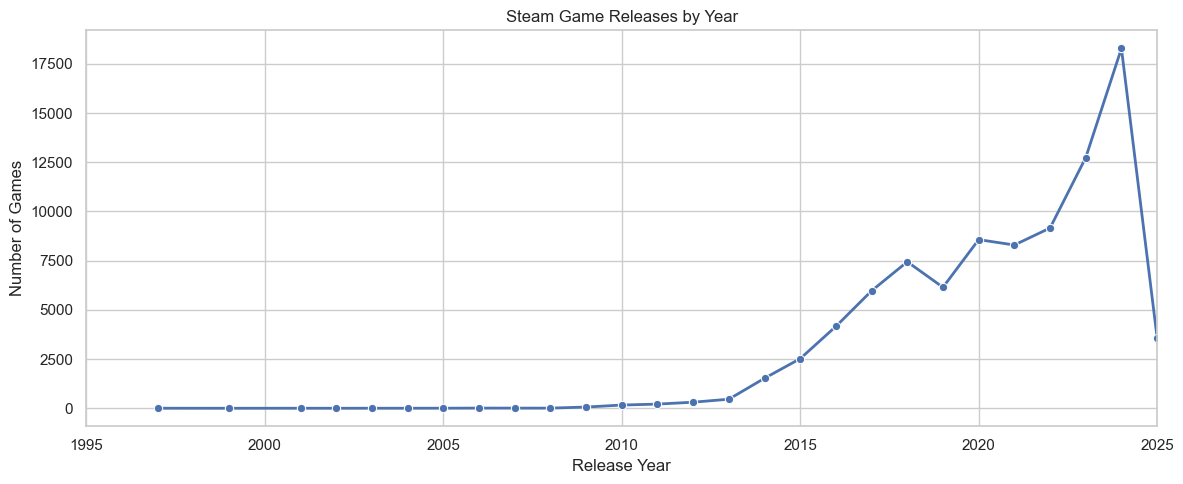

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/07_market_release_trend_by_year.png


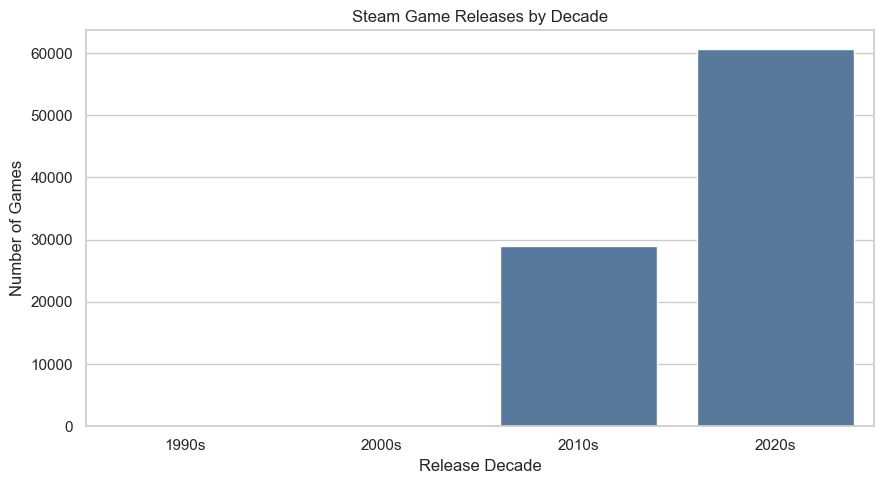

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/08_market_release_distribution_by_decade.png


In [5]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly_counts, x="release_year", y="game_count", marker="o", linewidth=2)
plt.title("Steam Game Releases by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Games")
plt.xlim(1995, SNAPSHOT_YEAR)
save_figure("07_market_release_trend_by_year.png")

plt.figure(figsize=(9, 5))
sns.barplot(data=decade_counts, x="release_decade", y="game_count", color="#4C78A8")
plt.title("Steam Game Releases by Decade")
plt.xlabel("Release Decade")
plt.ylabel("Number of Games")
save_figure("08_market_release_distribution_by_decade.png")

从发行年份趋势可以观察 Steam 游戏供给规模的变化。这里需要注意：发行数量增加不等于玩家需求同比例增加，它首先说明平台上可选择的游戏数量变多，也意味着市场竞争可能更激烈。

## 4. 价格结构与免费游戏比例

价格是市场结构的重要变量。Steam 上既有免费游戏，也有不同价位的付费游戏。由于价格字段存在少数极端高价值，绘制付费游戏价格分布时采用 99% 分位数截断，让主体分布更清晰。

In [6]:
price_df = df[["appid", "name", "price", "is_free", "review_count_calc", "positive_rate_calc"]].copy()
price_df["price"] = pd.to_numeric(price_df["price"], errors="coerce")

free_paid_summary = price_df.assign(price_type=np.where(price_df["is_free"], "Free", "Paid")).groupby("price_type").agg(
    game_count=("appid", "count"),
    median_price=("price", "median"),
    mean_price=("price", "mean"),
    median_review_count=("review_count_calc", "median"),
    mean_review_count=("review_count_calc", "mean"),
    median_positive_rate=("positive_rate_calc", "median")
).reset_index()
free_paid_summary["game_share"] = free_paid_summary["game_count"] / free_paid_summary["game_count"].sum()

display(free_paid_summary)

paid_prices = price_df.loc[price_df["price"] > 0, "price"].dropna()
price_cap = paid_prices.quantile(0.99) if len(paid_prices) else np.nan
print(f"Paid games: {len(paid_prices):,}; 99th percentile price cap: {price_cap:,.2f}")

display(price_df.sort_values("price", ascending=False).head(10)[["name", "price", "review_count_calc", "positive_rate_calc"]])

,price_type,game_count,median_price,mean_price,median_review_count,mean_review_count,median_positive_rate,game_share
0,Free,14160,0.00,0.00,0.00,"2,431.24",77.78,0.16
1,Paid,75458,4.99,8.68,15.00,"1,301.14",81.82,0.84


Paid games: 75,458; 99th percentile price cap: 49.99


,name,price,review_count_calc,positive_rate_calc
60133,The Leverage Game Business Edition,999.98,0,NaN
81168,The Leverage Game,999.98,1,100.00
64631,Ascent Free-Roaming VR Experience,999.00,7,85.71
84664,True Love,500.00,4,75.00
72266,Aartform Curvy 3D 3.0,299.90,45,71.11
72597,Houdini Indie,269.99,241,92.95
72863,3DF Zephyr Lite Steam Edition,249.00,72,97.22
54286,Beach Volleyball Competition,219.00,0,NaN
51082,Archaeology - Egypt,199.99,12,83.33
51088,3D PUZZLE - Hospital 3,199.99,0,NaN


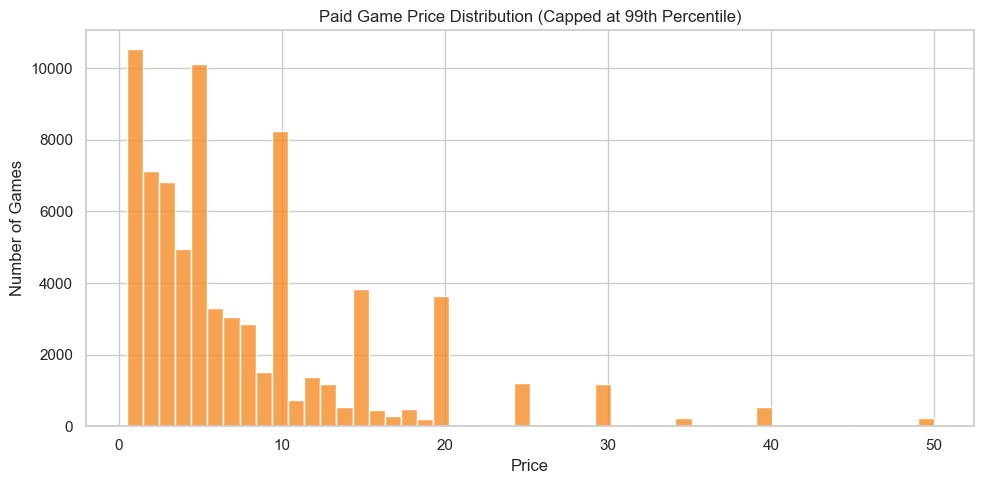

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/09_price_distribution_paid_games.png


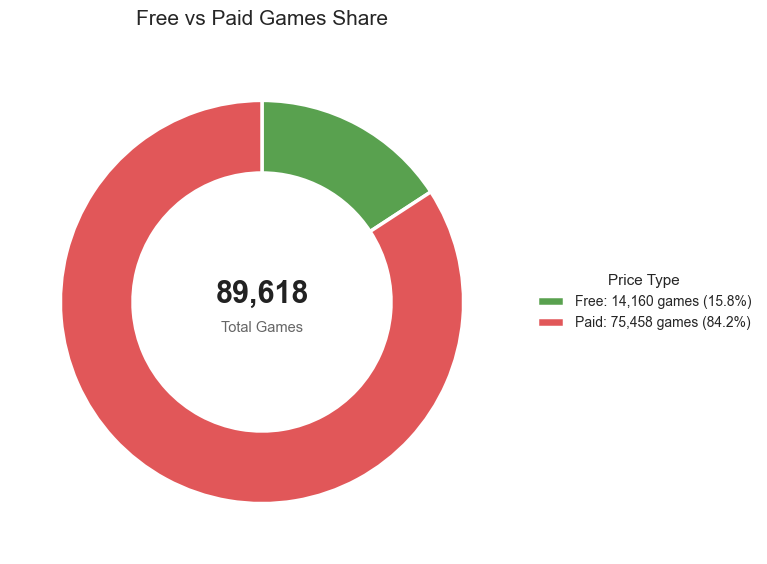

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/10_free_vs_paid_market_share.png


In [7]:
if len(paid_prices) > 0:
    plt.figure(figsize=(10, 5))
    sns.histplot(paid_prices[paid_prices <= price_cap], bins=50, color="#F58518")
    plt.title("Paid Game Price Distribution (Capped at 99th Percentile)")
    plt.xlabel("Price")
    plt.ylabel("Number of Games")
    save_figure("09_price_distribution_paid_games.png")

# 免费/付费是“整体占比”问题。这里使用甜甜圈图表达占比，
# 把具体数字放到图例中，避免文字挤在扇区里面影响阅读。
pie_data = free_paid_summary.copy().sort_values("price_type")
color_map = {"Free": "#59A14F", "Paid": "#E15759"}
colors = [color_map.get(label, "#9D9D9D") for label in pie_data["price_type"]]
total_games_for_pie = int(pie_data["game_count"].sum())
legend_labels = [
    f"{row.price_type}: {int(row.game_count):,} games ({row.game_share:.1%})"
    for row in pie_data.itertuples(index=False)
]

fig, ax = plt.subplots(figsize=(7.5, 5.8))
wedges, _ = ax.pie(
    pie_data["game_count"],
    startangle=90,
    counterclock=False,
    colors=colors,
    labels=None,
    wedgeprops={"width": 0.36, "edgecolor": "white", "linewidth": 2.5}
)

ax.text(
    0, 0.04,
    f"{total_games_for_pie:,}",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold",
    color="#222222"
)
ax.text(
    0, -0.13,
    "Total Games",
    ha="center",
    va="center",
    fontsize=10.5,
    color="#666666"
)

ax.legend(
    wedges,
    legend_labels,
    title="Price Type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)
ax.set_title("Free vs Paid Games Share", fontsize=15, pad=18)
ax.set_aspect("equal")
save_figure("10_free_vs_paid_market_share.png")

价格结构分析可以帮助说明 Steam 市场并不是单一的“售卖游戏”市场，而是同时包含免费游戏、低价长尾游戏和少量高价产品。后续分析玩家反馈时，可以进一步观察免费/付费是否与评论数量、好评率、在线人数等指标有关。

## 5. 平台支持结构

平台支持体现了 Steam 游戏的可达范围。这里分析 Windows、macOS、Linux 支持情况，以及单平台和多平台游戏的数量分布。

注意：平台支持与游戏质量没有直接因果关系，但它可能影响潜在玩家覆盖面。

In [8]:
platform_cols = [col for col in ["windows", "mac", "linux"] if col in df.columns]

platform_support = pd.DataFrame({
    "platform": platform_cols,
    "game_count": [int(df[col].sum()) for col in platform_cols]
})
platform_support["game_share"] = platform_support["game_count"] / len(df)

def platform_combo(row):
    active = [name.capitalize() for name in platform_cols if bool(row[name])]
    return "+".join(active) if active else "Unknown"

df["platform_combo"] = df.apply(platform_combo, axis=1)
platform_combo_counts = df["platform_combo"].value_counts().reset_index()
platform_combo_counts.columns = ["platform_combo", "game_count"]
platform_combo_counts["game_share"] = platform_combo_counts["game_count"] / len(df)

platform_count_summary = df.groupby("platform_count").agg(
    game_count=("appid", "count"),
    median_review_count=("review_count_calc", "median"),
    median_positive_rate=("positive_rate_calc", "median"),
    median_price=("price", "median")
).reset_index()
platform_count_summary["game_share"] = platform_count_summary["game_count"] / platform_count_summary["game_count"].sum()

display(platform_support)
display(platform_combo_counts.head(10))
display(platform_count_summary)

,platform,game_count,game_share
0,windows,89588,1.00
1,mac,17438,0.19
2,linux,12627,0.14


,platform_combo,game_count,game_share
0,Windows,68931,0.77
1,Windows+Mac+Linux,9377,0.10
2,Windows+Mac,8039,0.09
3,Windows+Linux,3241,0.04
4,Mac,21,0.00
5,Linux,8,0.00
6,Mac+Linux,1,0.00


,platform_count,game_count,median_review_count,median_positive_rate,median_price,game_share
0,1,68960,11.00,80.00,3.99,0.77
1,2,11281,21.00,85.56,4.99,0.13
2,3,9377,40.00,84.21,4.99,0.10


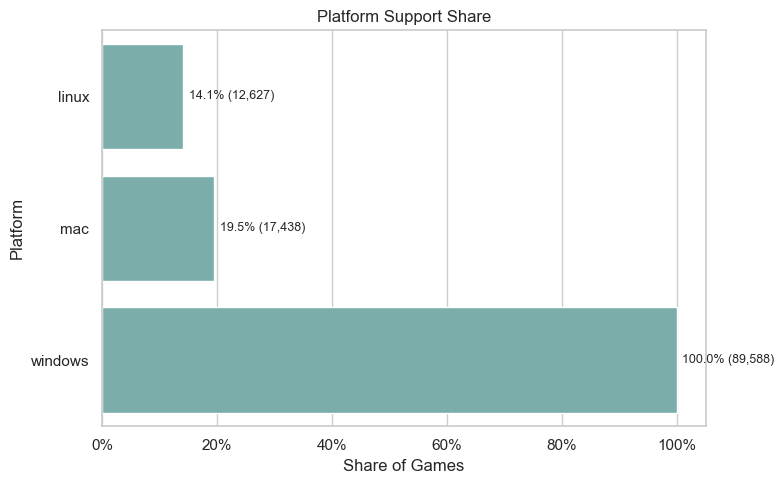

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/11_platform_support_counts.png


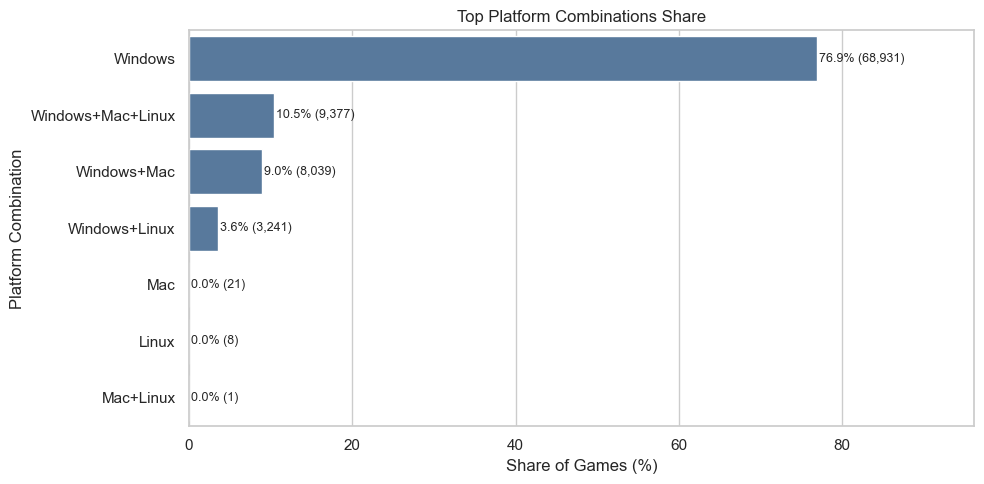

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/12_platform_combination_distribution.png


In [9]:
# 平台支持比例差异不只看绝对数量，还直接标注占比，避免柱子长度相近时不直观。
plot_platform = platform_support.sort_values("game_share", ascending=True).copy()
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=plot_platform, y="platform", x="game_share", color="#72B7B2")
plt.title("Platform Support Share")
plt.xlabel("Share of Games")
plt.ylabel("Platform")
ax.set_xlim(0, min(1.05, max(1.0, plot_platform["game_share"].max() * 1.15)))
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
for i, row in plot_platform.reset_index(drop=True).iterrows():
    ax.text(row["game_share"] + 0.01, i, f"{row['game_share']:.1%} ({row['game_count']:,})", va="center", fontsize=9)
save_figure("11_platform_support_counts.png")

plt.figure(figsize=(10, 5))
plot_combo = platform_combo_counts.head(8).copy()
plot_combo["game_share_pct"] = plot_combo["game_share"] * 100
ax = sns.barplot(data=plot_combo, y="platform_combo", x="game_share_pct", color="#4C78A8")
plt.title("Top Platform Combinations Share")
plt.xlabel("Share of Games (%)")
plt.ylabel("Platform Combination")
for i, row in plot_combo.reset_index(drop=True).iterrows():
    ax.text(row["game_share_pct"] + 0.25, i, f"{row['game_share']:.1%} ({row['game_count']:,})", va="center", fontsize=9)
ax.set_xlim(0, plot_combo["game_share_pct"].max() * 1.25)
save_figure("12_platform_combination_distribution.png")

平台结构可以反映 Steam 生态中的技术适配情况。通常 Windows 支持会占主导，而 Mac/Linux 支持比例能够体现跨平台覆盖程度。这个部分为后续分析“多平台是否更容易获得玩家关注”提供背景。

## 6. 类型、分类与标签结构

`genres`、`categories` 和 `tags` 是理解 Steam 市场定位的关键字段：

- `genres` 更像官方或较粗粒度的游戏类型；
- `categories` 更偏功能和玩法支持，例如单人、多人、成就、控制器支持等；
- `tags` 更接近玩家和商店语境中的市场定位词汇。

本节先统计高频类型、分类和标签，为后续 Notebook 06 的标签共现与定位分析打基础。

In [10]:
genre_long = explode_items(df, "genres_items", "genre")
category_long = explode_items(df, "categories_items", "category")
tag_long = explode_items(df, "tags_items", "tag")


def frequency_table(long_df, item_col, top_n=20):
    if long_df.empty:
        return pd.DataFrame(columns=[item_col, "game_count", "game_share"])
    out = long_df[item_col].value_counts().reset_index()
    out.columns = [item_col, "game_count"]
    out["game_share"] = out["game_count"] / df["appid"].nunique()
    return out.head(top_n)

top_genres = frequency_table(genre_long, "genre", 20)
top_categories = frequency_table(category_long, "category", 20)
top_tags = frequency_table(tag_long, "tag", 25)

display(top_genres)
display(top_categories)
display(top_tags)

,genre,game_count,game_share
0,Indie,63189,0.71
1,Casual,38699,0.43
2,Action,36842,0.41
3,Adventure,35452,0.40
4,Simulation,18570,0.21
5,Strategy,17366,0.19
6,RPG,16342,0.18
7,Early Access,9113,0.10
8,Free To Play,8867,0.10
9,Sports,3939,0.04


,category,game_count,game_share
0,Single-player,84399,0.94
1,Family Sharing,75028,0.84
2,Steam Achievements,42841,0.48
3,Steam Cloud,22721,0.25
4,Full controller support,19535,0.22
5,Multi-player,16365,0.18
6,Partial Controller Support,11355,0.13
7,Steam Trading Cards,10431,0.12
8,PvP,10337,0.12
9,Co-op,8771,0.10


,tag,game_count,game_share
0,Indie,43408,0.48
1,Singleplayer,42723,0.48
2,Action,32315,0.36
3,Casual,31832,0.36
4,Adventure,30772,0.34
5,2D,22695,0.25
6,Simulation,15663,0.17
7,Strategy,15465,0.17
8,3D,14950,0.17
9,Puzzle,13923,0.16


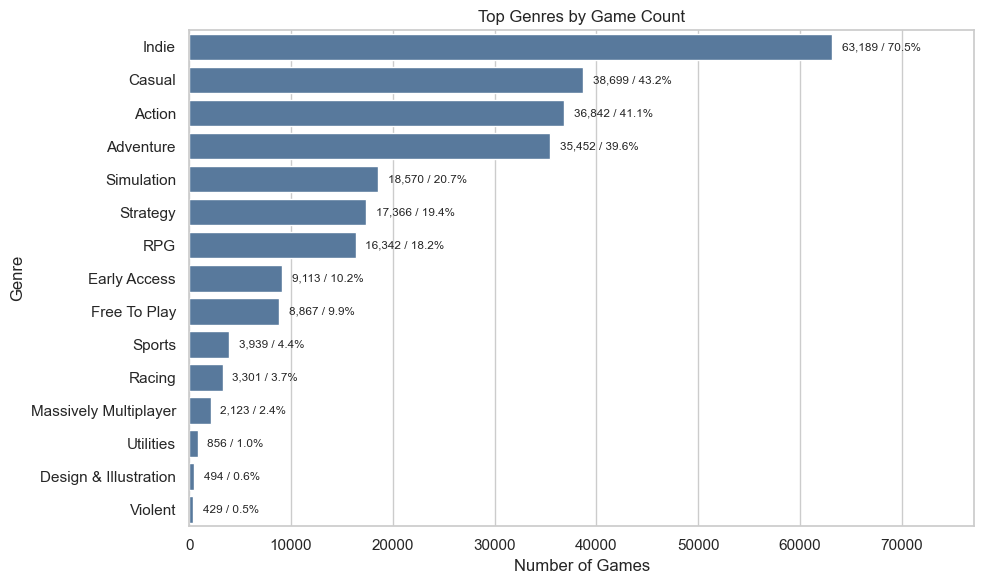

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/13_top_genres_by_game_count.png


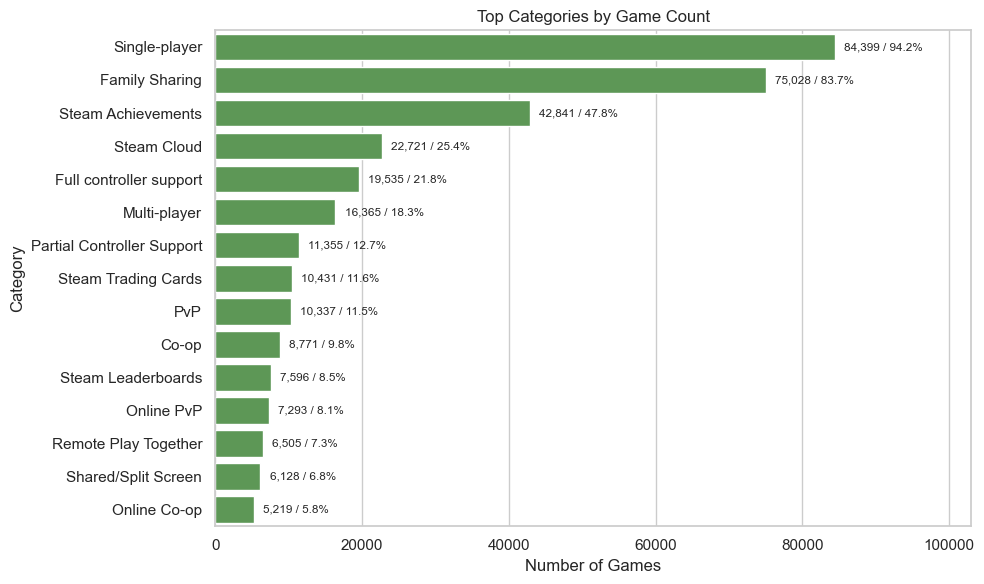

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/14_top_categories_by_game_count.png


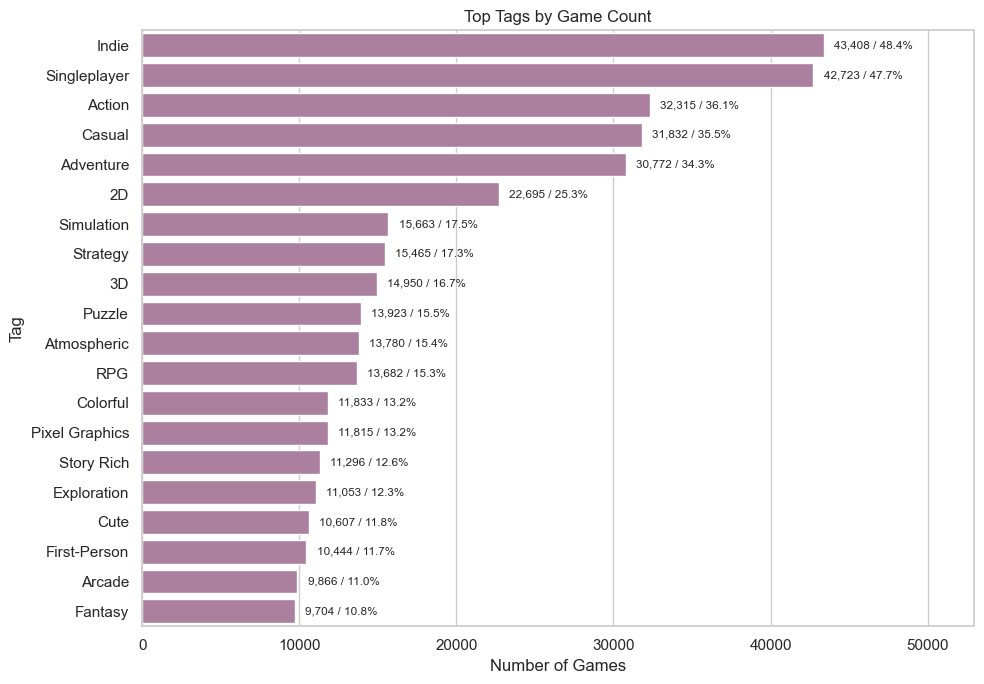

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/15_top_tags_by_game_count.png


In [11]:
def add_count_share_labels(ax, data, count_col="game_count", share_col="game_share"):
    """给水平柱状图加数量和占比，减少只靠柱长比较带来的误读。"""
    max_count = data[count_col].max()
    ax.set_xlim(0, max_count * 1.22)
    for i, row in data.reset_index(drop=True).iterrows():
        ax.text(
            row[count_col] + max_count * 0.015,
            i,
            f"{int(row[count_col]):,} / {row[share_col]:.1%}",
            va="center",
            fontsize=8.5
        )

plt.figure(figsize=(10, 6))
plot_genres = top_genres.head(15).copy()
ax = sns.barplot(data=plot_genres, y="genre", x="game_count", color="#4C78A8")
plt.title("Top Genres by Game Count")
plt.xlabel("Number of Games")
plt.ylabel("Genre")
add_count_share_labels(ax, plot_genres)
save_figure("13_top_genres_by_game_count.png")

plt.figure(figsize=(10, 6))
plot_categories = top_categories.head(15).copy()
ax = sns.barplot(data=plot_categories, y="category", x="game_count", color="#54A24B")
plt.title("Top Categories by Game Count")
plt.xlabel("Number of Games")
plt.ylabel("Category")
add_count_share_labels(ax, plot_categories)
save_figure("14_top_categories_by_game_count.png")

plt.figure(figsize=(10, 7))
plot_tags = top_tags.head(20).copy()
ax = sns.barplot(data=plot_tags, y="tag", x="game_count", color="#B279A2")
plt.title("Top Tags by Game Count")
plt.xlabel("Number of Games")
plt.ylabel("Tag")
add_count_share_labels(ax, plot_tags)
save_figure("15_top_tags_by_game_count.png")

类型、分类和标签的频次可以说明 Steam 市场中哪些内容供给最多。需要注意的是，高频并不必然代表机会更大：高频标签也可能意味着竞争更激烈。这一点会在后续标签定位 Notebook 中继续展开。

## 7. 开发商、发行商长尾与市场集中度

Steam 市场的另一个重要结构特征是“长尾”：大量开发商/发行商只发布少量游戏，少数实体发布很多游戏。

这里分别统计开发商和发行商的游戏数量分布，并用集中度指标观察头部实体占比。

In [12]:
dev_long = explode_items(df, "developers_items", "developer")
pub_long = explode_items(df, "publishers_items", "publisher")

dev_counts = dev_long["developer"].value_counts().reset_index()
dev_counts.columns = ["entity", "game_count"]
dev_counts["entity_type"] = "Developer"

pub_counts = pub_long["publisher"].value_counts().reset_index()
pub_counts.columns = ["entity", "game_count"]
pub_counts["entity_type"] = "Publisher"

top_entities = pd.concat([dev_counts.head(15), pub_counts.head(15)], ignore_index=True)

def concentration_table(counts, entity_type):
    counts = counts.copy().sort_values("game_count", ascending=False)
    total_assignments = counts["game_count"].sum()
    unique_entities = len(counts)
    rows = []
    for n in [1, 5, 10, 50, 100]:
        rows.append({
            "entity_type": entity_type,
            "top_n": n,
            "unique_entities": unique_entities,
            "top_n_share": counts.head(n)["game_count"].sum() / total_assignments if total_assignments else np.nan,
            "max_games_by_one_entity": counts["game_count"].max() if len(counts) else np.nan,
            "median_games_per_entity": counts["game_count"].median() if len(counts) else np.nan,
        })
    return pd.DataFrame(rows)

concentration = pd.concat([
    concentration_table(dev_counts, "Developer"),
    concentration_table(pub_counts, "Publisher")
], ignore_index=True)

display(dev_counts.head(20))
display(pub_counts.head(20))
display(concentration)

,entity,game_count,entity_type
0,Inc.,487,Developer
1,LLC,438,Developer
2,Ltd.,366,Developer
3,LTD.,198,Developer
4,EroticGamesClub,196,Developer
5,Choice of Games,158,Developer
6,Laush Dmitriy Sergeevich,140,Developer
7,Boogygames Studios,133,Developer
8,Creobit,124,Developer
9,Ltd,119,Developer


,entity,game_count,entity_type
0,Inc.,585,Publisher
1,LLC,489,Publisher
2,Big Fish Games,484,Publisher
3,Ltd.,408,Publisher
4,8floor,237,Publisher
5,EroticGamesClub,196,Publisher
6,Conglomerate 5,186,Publisher
7,LTD.,184,Publisher
8,HH-Games,169,Publisher
9,Laush Studio,160,Publisher


,entity_type,top_n,unique_entities,top_n_share,max_games_by_one_entity,median_games_per_entity
0,Developer,1,60189,0.00,487,1.00
1,Developer,5,60189,0.02,487,1.00
2,Developer,10,60189,0.02,487,1.00
3,Developer,50,60189,0.05,487,1.00
4,Developer,100,60189,0.07,487,1.00
5,Publisher,1,49860,0.01,585,1.00
6,Publisher,5,49860,0.02,585,1.00
7,Publisher,10,49860,0.03,585,1.00
8,Publisher,50,49860,0.08,585,1.00
9,Publisher,100,49860,0.11,585,1.00


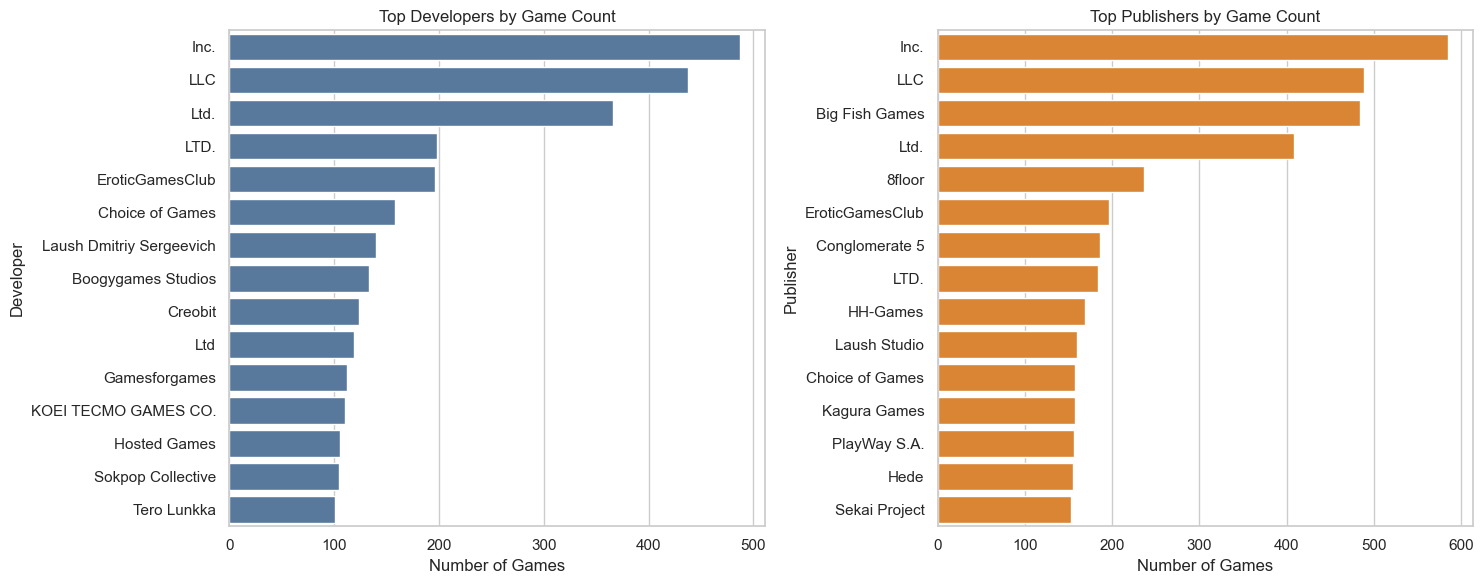

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/16_top_developers_publishers_by_game_count.png


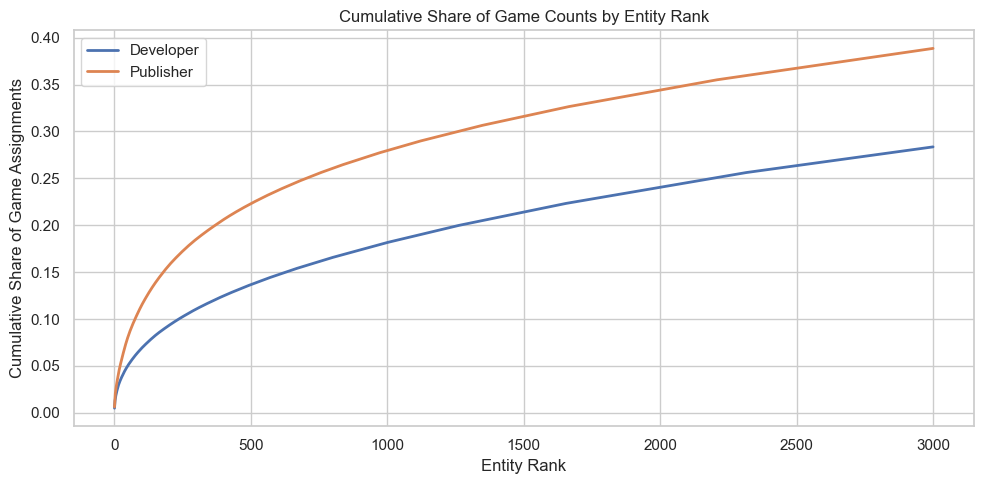

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/17_developer_publisher_long_tail_cumulative_share.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=False)

sns.barplot(data=dev_counts.head(15), y="entity", x="game_count", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top Developers by Game Count")
axes[0].set_xlabel("Number of Games")
axes[0].set_ylabel("Developer")

sns.barplot(data=pub_counts.head(15), y="entity", x="game_count", ax=axes[1], color="#F58518")
axes[1].set_title("Top Publishers by Game Count")
axes[1].set_xlabel("Number of Games")
axes[1].set_ylabel("Publisher")

save_figure("16_top_developers_publishers_by_game_count.png")

plt.figure(figsize=(10, 5))
for counts, label in [(dev_counts, "Developer"), (pub_counts, "Publisher")]:
    sorted_counts = counts["game_count"].sort_values(ascending=False).reset_index(drop=True)
    cumulative_share = sorted_counts.cumsum() / sorted_counts.sum()
    x = np.arange(1, len(cumulative_share) + 1)
    plot_limit = min(3000, len(cumulative_share))
    plt.plot(x[:plot_limit], cumulative_share.iloc[:plot_limit], label=label, linewidth=2)

plt.title("Cumulative Share of Game Counts by Entity Rank")
plt.xlabel("Entity Rank")
plt.ylabel("Cumulative Share of Game Assignments")
plt.legend()
save_figure("17_developer_publisher_long_tail_cumulative_share.png")

长尾结构说明 Steam 市场不是由少数开发商或发行商完全覆盖。头部实体可能拥有较高可见度和较多作品，但大量中小开发者共同构成了平台内容供给。这一点也解释了为什么后续分析不能只看头部热门游戏。

## 8. 2024 到 2025 快照的市场规模变化

本节做一个轻量级快照对比，使用 `games_may2024_cleaned.csv` 和 `games_march2025_cleaned.csv` 中的少量字段，比较两个时间点的游戏数量、免费游戏比例、多平台比例和新增游戏情况。

这里的重点是市场规模变化，不深入分析玩家反馈指标；更详细的评论和热度分析会放到 Notebook 05。

In [14]:
def normalize_column_name(name):
    return str(name).strip().lower().replace(" ", "_").replace("-", "_")


def read_snapshot_for_market(path, snapshot_label):
    if not path.exists():
        print(f"Snapshot file not found: {path}")
        return None

    header = pd.read_csv(path, nrows=0).columns.tolist()
    normalized_to_original = {normalize_column_name(col): col for col in header}
    wanted = ["appid", "name", "release_date", "price", "windows", "mac", "linux", "genres", "categories", "tags", "developers", "publishers"]

    # 兼容 2024 文件中的 AppID 和 2025 文件中的 appid。
    usecols = []
    rename_map = {}
    for standard_name in wanted:
        original_name = normalized_to_original.get(standard_name)
        if original_name is not None:
            usecols.append(original_name)
            rename_map[original_name] = standard_name

    snap = pd.read_csv(path, usecols=usecols, low_memory=False)
    snap = snap.rename(columns=rename_map)
    snap["snapshot"] = snapshot_label

    if "release_date" in snap.columns:
        snap["release_date_parsed"] = pd.to_datetime(snap["release_date"], errors="coerce")
        snap["release_year"] = snap["release_date_parsed"].dt.year
    if "price" in snap.columns:
        snap["price"] = pd.to_numeric(snap["price"], errors="coerce")
        snap["is_free"] = snap["price"].fillna(0).eq(0)
    existing_platforms = [col for col in ["windows", "mac", "linux"] if col in snap.columns]
    for col in existing_platforms:
        snap[col] = snap[col].astype(str).str.lower().isin(["true", "1", "yes"])
    if existing_platforms:
        snap["platform_count"] = snap[existing_platforms].sum(axis=1)
        snap["is_multi_platform"] = snap["platform_count"] >= 2
    return snap

may2024_path = RAW_DIR / "games_may2024_cleaned.csv"
march2025_path = RAW_DIR / "games_march2025_cleaned.csv"

snap_may = read_snapshot_for_market(may2024_path, "May 2024")
snap_mar = read_snapshot_for_market(march2025_path, "March 2025")

snapshots = [snap for snap in [snap_may, snap_mar] if snap is not None]

if len(snapshots) == 2 and all("appid" in snap.columns for snap in snapshots):
    snapshot_summary = []
    for snap in snapshots:
        snapshot_summary.append({
            "snapshot": snap["snapshot"].iloc[0],
            "rows": len(snap),
            "unique_appids": snap["appid"].nunique() if "appid" in snap.columns else np.nan,
            "free_game_share": snap["is_free"].mean() if "is_free" in snap.columns else np.nan,
            "median_price": snap["price"].median() if "price" in snap.columns else np.nan,
            "multi_platform_share": snap["is_multi_platform"].mean() if "is_multi_platform" in snap.columns else np.nan,
            "valid_release_year_min": snap["release_year"].dropna().min() if "release_year" in snap.columns else np.nan,
            "valid_release_year_max": snap["release_year"].dropna().max() if "release_year" in snap.columns else np.nan,
        })
    snapshot_summary = pd.DataFrame(snapshot_summary)
    display(snapshot_summary)

    may_ids = set(snap_may["appid"].dropna().astype(int))
    mar_ids = set(snap_mar["appid"].dropna().astype(int))
    new_ids = mar_ids - may_ids
    removed_ids = may_ids - mar_ids
    print(f"New appids in March 2025 snapshot compared with May 2024: {len(new_ids):,}")
    print(f"Appids in May 2024 but not in March 2025 cleaned snapshot: {len(removed_ids):,}")

    new_games_2025 = snap_mar[snap_mar["appid"].isin(new_ids)].copy()
    new_games_2025["genres_items"] = new_games_2025["genres"].apply(parse_multivalue) if "genres" in new_games_2025.columns else [[] for _ in range(len(new_games_2025))]
    new_genre_long = explode_items(new_games_2025, "genres_items", "genre")
    top_new_genres = frequency_table(new_genre_long, "genre", 15)
    display(top_new_genres)
else:
    snapshot_summary = None
    new_games_2025 = pd.DataFrame()
    top_new_genres = pd.DataFrame()
    print("未能同时读取 2024 和 2025 快照，或缺少 appid 字段，因此跳过快照对比图。")

,snapshot,rows,unique_appids,free_game_share,median_price,multi_platform_share,valid_release_year_min,valid_release_year_max
0,May 2024,83646,83646,0.15,4.99,0.23,1997,2024
1,March 2025,89618,89618,0.16,4.99,0.23,1997,2025


New appids in March 2025 snapshot compared with May 2024: 14,882
Appids in May 2024 but not in March 2025 cleaned snapshot: 8,910


,genre,game_count,game_share
0,Indie,10293,0.11
1,Casual,6976,0.08
2,Adventure,5847,0.07
3,Action,5595,0.06
4,Simulation,3384,0.04
5,RPG,2909,0.03
6,Strategy,2869,0.03
7,Free To Play,2387,0.03
8,Early Access,1997,0.02
9,Sports,561,0.01


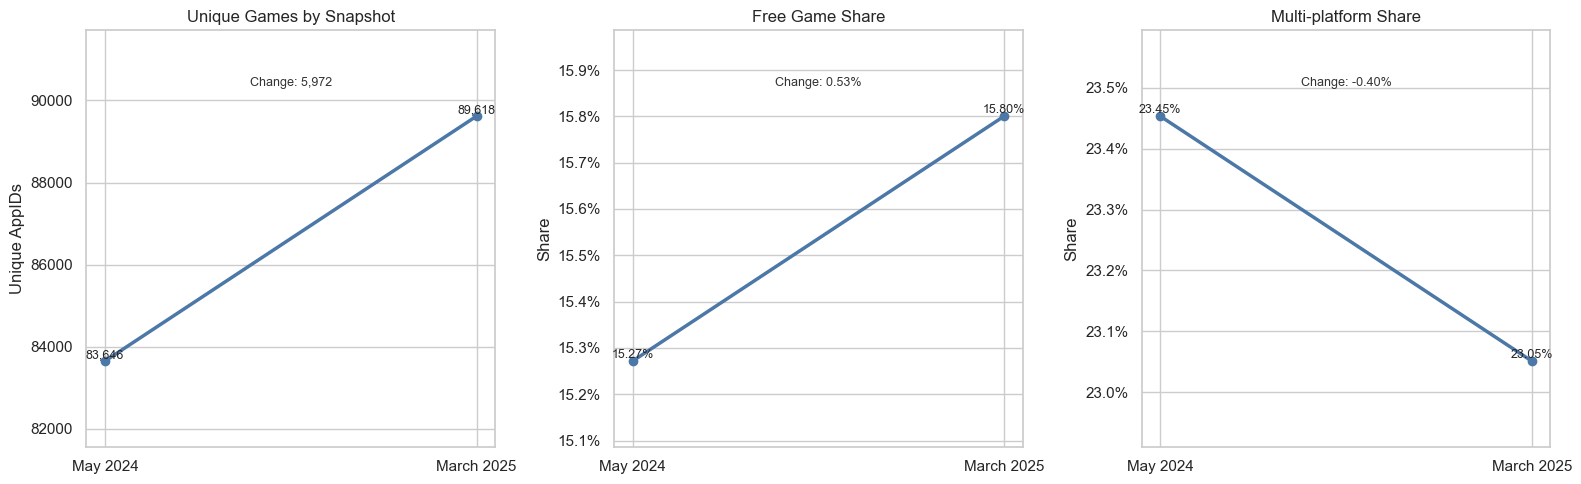

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/18_snapshot_market_structure_comparison.png


In [15]:
if snapshot_summary is not None:
    # 只有两个快照时，变化线比两根柱子更容易看出方向和差值。
    plot_snapshot = snapshot_summary.set_index("snapshot").loc[["May 2024", "March 2025"]].reset_index()
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    def draw_snapshot_change(ax, metric, title, ylabel, formatter):
        values = plot_snapshot[metric].to_numpy(dtype=float)
        ax.plot([0, 1], values, marker="o", linewidth=2.5, color="#4C78A8")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(plot_snapshot["snapshot"], rotation=0)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        if ylabel == "Share":
            ax.yaxis.set_major_formatter(lambda y, pos: f"{y:.1%}")
        lower = np.nanmin(values)
        upper = np.nanmax(values)
        padding = (upper - lower) * 0.35 if upper != lower else max(abs(upper) * 0.1, 1)
        ax.set_ylim(lower - padding, upper + padding)
        for x, value in zip([0, 1], values):
            ax.text(x, value, formatter(value), ha="center", va="bottom", fontsize=9)
        delta = values[1] - values[0]
        ax.text(0.5, upper + padding * 0.35, f"Change: {formatter(delta)}", ha="center", fontsize=9, color="#333333")

    draw_snapshot_change(axes[0], "unique_appids", "Unique Games by Snapshot", "Unique AppIDs", lambda x: f"{x:,.0f}")
    draw_snapshot_change(axes[1], "free_game_share", "Free Game Share", "Share", lambda x: f"{x:.2%}")
    draw_snapshot_change(axes[2], "multi_platform_share", "Multi-platform Share", "Share", lambda x: f"{x:.2%}")

    save_figure("18_snapshot_market_structure_comparison.png")

快照对比可以说明数据集不仅是一个静态表格，也能用于观察平台生态变化。由于两个快照的采集和清洗方式可能存在差异，本节结论应谨慎表述为“观察到的变化”，而不是完整的因果解释。

## 9. 市场结构小结

最后，本节根据前面的实际统计结果自动生成一段中文总结。这样可以避免在 Notebook 尚未运行时手写具体数字，也方便后续直接复制到课程报告草稿中继续润色。

In [16]:
# 基于实际运行结果生成报告式小结，避免手写数字造成不一致。
# 如果用户重启内核后只运行最后一个单元，本单元会尝试重新读取必要数据。
from pathlib import Path
import ast
import numpy as np
import pandas as pd

try:
    from IPython.display import display, Markdown
except Exception:
    display = None
    Markdown = None

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent
if "PROCESSED_DIR" not in globals():
    PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
if "RAW_DIR" not in globals():
    RAW_DIR = PROJECT_ROOT / "data" / "raw" / "archive"
if "SNAPSHOT_YEAR" not in globals():
    SNAPSHOT_YEAR = 2025
if "df" not in globals():
    feature_path = PROCESSED_DIR / "steam_march2025_features.parquet"
    if not feature_path.exists():
        raise FileNotFoundError(f"未找到 {feature_path}，请先运行 Notebook 03。")
    df = pd.read_parquet(feature_path)


def _parse_multivalue_for_summary(value):
    if value is None:
        return []
    if isinstance(value, float) and pd.isna(value):
        return []
    if isinstance(value, list):
        raw_items = value
    elif isinstance(value, dict):
        raw_items = list(value.keys())
    else:
        text = str(value).strip()
        if not text or text.lower() in {"nan", "none", "[]", "{}"}:
            return []
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, dict):
                raw_items = list(parsed.keys())
            elif isinstance(parsed, (list, tuple, set)):
                raw_items = list(parsed)
            else:
                raw_items = [parsed]
        except (ValueError, SyntaxError):
            raw_items = text.split(";") if ";" in text else text.split(",") if "," in text else [text]

    cleaned = []
    for item in raw_items:
        item_text = str(item).strip().strip("'\"")
        parts = item_text.split("|") if "|" in item_text else [item_text]
        for part in parts:
            part_text = str(part).strip().strip("'\"")
            if part_text and part_text.lower() not in {"nan", "none"}:
                cleaned.append(part_text)
    return cleaned


def _frequency_from_column(data, source_col, item_col):
    if f"{source_col}_items" in data.columns:
        items = data[["appid", f"{source_col}_items"]].copy()
        items[f"{source_col}_items"] = items[f"{source_col}_items"].apply(_parse_multivalue_for_summary)
        exploded = items.explode(f"{source_col}_items").rename(columns={f"{source_col}_items": item_col})
    elif source_col in data.columns:
        items = data[["appid", source_col]].copy()
        items[source_col] = items[source_col].apply(_parse_multivalue_for_summary)
        exploded = items.explode(source_col).rename(columns={source_col: item_col})
    else:
        return pd.DataFrame(columns=[item_col, "game_count", "game_share"])
    exploded[item_col] = exploded[item_col].astype(str).str.strip()
    exploded = exploded[(exploded[item_col] != "") & (exploded[item_col].str.lower() != "nan")]
    out = exploded[item_col].value_counts().reset_index()
    out.columns = [item_col, "game_count"]
    out["game_share"] = out["game_count"] / data["appid"].nunique()
    return out


def _entity_counts(data, source_col):
    freq = _frequency_from_column(data, source_col, "entity")
    return freq[["entity", "game_count"]] if not freq.empty else pd.DataFrame(columns=["entity", "game_count"])


def _top100_share(counts):
    total = counts["game_count"].sum()
    return counts.sort_values("game_count", ascending=False).head(100)["game_count"].sum() / total if total else np.nan

# 如果前面的中间变量不存在，就在这里恢复最小必要计算。
if "year_df" not in globals():
    valid_year_mask = df["release_year"].between(1970, SNAPSHOT_YEAR)
    year_df = df.loc[valid_year_mask].copy()
if "yearly_counts" not in globals():
    yearly_counts = year_df.groupby("release_year").size().reset_index(name="game_count")
if "top_genres" not in globals():
    top_genres = _frequency_from_column(df, "genres", "genre")
if "top_categories" not in globals():
    top_categories = _frequency_from_column(df, "categories", "category")
if "top_tags" not in globals():
    top_tags = _frequency_from_column(df, "tags", "tag")
if "dev_counts" not in globals():
    dev_counts = _entity_counts(df, "developers")
if "pub_counts" not in globals():
    pub_counts = _entity_counts(df, "publishers")
if "snapshot_summary" not in globals():
    may_path = RAW_DIR / "games_may2024_cleaned.csv"
    mar_path = RAW_DIR / "games_march2025_cleaned.csv"
    if may_path.exists() and mar_path.exists():
        def _read_snapshot_ids(path, label):
            header = pd.read_csv(path, nrows=0).columns.tolist()
            id_col = "AppID" if "AppID" in header else "appid" if "appid" in header else None
            usecols = [col for col in [id_col, "price", "windows", "mac", "linux"] if col is not None and col in header]
            snap = pd.read_csv(path, usecols=usecols, low_memory=False)
            if id_col and id_col != "appid":
                snap = snap.rename(columns={id_col: "appid"})
            snap["snapshot"] = label
            if "price" in snap.columns:
                snap["price"] = pd.to_numeric(snap["price"], errors="coerce")
                snap["is_free"] = snap["price"].fillna(0).eq(0)
            platform_cols = [col for col in ["windows", "mac", "linux"] if col in snap.columns]
            for col in platform_cols:
                snap[col] = snap[col].astype(str).str.lower().isin(["true", "1", "yes"])
            if platform_cols:
                snap["platform_count"] = snap[platform_cols].sum(axis=1)
                snap["is_multi_platform"] = snap["platform_count"] >= 2
            return snap
        snaps = [_read_snapshot_ids(may_path, "May 2024"), _read_snapshot_ids(mar_path, "March 2025")]
        snapshot_summary = pd.DataFrame([
            {
                "snapshot": snap["snapshot"].iloc[0],
                "unique_appids": snap["appid"].nunique(),
                "free_game_share": snap["is_free"].mean() if "is_free" in snap.columns else np.nan,
                "multi_platform_share": snap["is_multi_platform"].mean() if "is_multi_platform" in snap.columns else np.nan,
            }
            for snap in snaps
        ])
    else:
        snapshot_summary = None

total_games = len(df)
valid_release_games = len(year_df)
release_min = int(year_df["release_year"].min())
release_max = int(year_df["release_year"].max())
peak_release_year = int(yearly_counts.loc[yearly_counts["game_count"].idxmax(), "release_year"])
peak_release_count = int(yearly_counts["game_count"].max())
free_share = float(df["is_free"].mean()) if "is_free" in df.columns else np.nan
multi_share = float(df["is_multi_platform"].mean()) if "is_multi_platform" in df.columns else np.nan
median_price = float(df["price"].median()) if "price" in df.columns else np.nan
top_genre = top_genres.iloc[0]["genre"] if len(top_genres) else "N/A"
top_category = top_categories.iloc[0]["category"] if len(top_categories) else "N/A"
top_tag = top_tags.iloc[0]["tag"] if len(top_tags) else "N/A"
dev_top100_share = _top100_share(dev_counts)
pub_top100_share = _top100_share(pub_counts)

if snapshot_summary is not None and set(["May 2024", "March 2025"]).issubset(set(snapshot_summary["snapshot"])):
    may_games = int(snapshot_summary.loc[snapshot_summary["snapshot"] == "May 2024", "unique_appids"].iloc[0])
    mar_games = int(snapshot_summary.loc[snapshot_summary["snapshot"] == "March 2025", "unique_appids"].iloc[0])
    snapshot_text = f"从快照对比看，May 2024 到 March 2025 的唯一 AppID 数量从 {may_games:,} 增加到 {mar_games:,}，说明数据中观察到的 Steam 游戏供给规模继续扩张。"
else:
    snapshot_text = "由于未能同时读取两个原始快照，本次没有生成 2024 到 2025 的市场规模对比。"

summary_md = f"""
### 初步结论

1. 当前分析使用 Notebook 03 生成的特征数据，共包含 **{total_games:,}** 款 Steam 游戏，其中 **{valid_release_games:,}** 条记录具有 1970 到 {SNAPSHOT_YEAR} 之间的有效发行年份。有效发行年份范围为 **{release_min} 到 {release_max}**。

2. 从年度发行趋势看，数据集中游戏发行数量最多的年份是 **{peak_release_year}**，对应 **{peak_release_count:,}** 款游戏。这说明 Steam 游戏供给在近年高度集中，平台竞争环境呈现明显扩张特征。

3. 价格结构方面，免费游戏占比约为 **{free_share:.2%}**，整体价格中位数为 **{median_price:.2f}**。这表明 Steam 市场同时包含免费游戏、低价付费游戏和少量高价游戏，价格层次较丰富。

4. 平台支持方面，多平台游戏占比约为 **{multi_share:.2%}**。Windows 支持仍然是 Steam 市场的基础结构，Mac/Linux 支持和多平台组合可以作为后续分析玩家覆盖面的辅助变量。

5. 内容结构方面，出现频次最高的类型、分类和标签分别是 **{top_genre}**、**{top_category}** 和 **{top_tag}**。这些高频词反映了 Steam 市场上最常见的内容供给和商店定位方式，但也可能意味着更强的竞争。

6. 开发商和发行商结构呈现明显长尾特征。前 100 个开发商覆盖约 **{dev_top100_share:.2%}** 的开发商-游戏关系，前 100 个发行商覆盖约 **{pub_top100_share:.2%}** 的发行商-游戏关系。说明 Steam 市场既有头部主体，也有大量中小主体共同参与。

7. {snapshot_text}

8. 本 Notebook 的分析仍属于描述性市场结构分析，不能直接说明因果关系。后续 Notebook 05 将进一步关注评论数、好评率、推荐数、在线人数和游玩时长等玩家反馈与热度指标。
"""

if display is not None and Markdown is not None:
    display(Markdown(summary_md))
else:
    print(summary_md)


### 初步结论

1. 当前分析使用 Notebook 03 生成的特征数据，共包含 **89,618** 款 Steam 游戏，其中 **89,618** 条记录具有 1970 到 2025 之间的有效发行年份。有效发行年份范围为 **1997 到 2025**。

2. 从年度发行趋势看，数据集中游戏发行数量最多的年份是 **2024**，对应 **18,282** 款游戏。这说明 Steam 游戏供给在近年高度集中，平台竞争环境呈现明显扩张特征。

3. 价格结构方面，免费游戏占比约为 **15.80%**，整体价格中位数为 **4.99**。这表明 Steam 市场同时包含免费游戏、低价付费游戏和少量高价游戏，价格层次较丰富。

4. 平台支持方面，多平台游戏占比约为 **23.05%**。Windows 支持仍然是 Steam 市场的基础结构，Mac/Linux 支持和多平台组合可以作为后续分析玩家覆盖面的辅助变量。

5. 内容结构方面，出现频次最高的类型、分类和标签分别是 **Indie**、**Single-player** 和 **Indie**。这些高频词反映了 Steam 市场上最常见的内容供给和商店定位方式，但也可能意味着更强的竞争。

6. 开发商和发行商结构呈现明显长尾特征。前 100 个开发商覆盖约 **6.87%** 的开发商-游戏关系，前 100 个发行商覆盖约 **11.44%** 的发行商-游戏关系。说明 Steam 市场既有头部主体，也有大量中小主体共同参与。

7. 从快照对比看，May 2024 到 March 2025 的唯一 AppID 数量从 83,646 增加到 89,618，说明数据中观察到的 Steam 游戏供给规模继续扩张。

8. 本 Notebook 的分析仍属于描述性市场结构分析，不能直接说明因果关系。后续 Notebook 05 将进一步关注评论数、好评率、推荐数、在线人数和游玩时长等玩家反馈与热度指标。
